# 🛒 E-Commerce Sales Analysis: Comprehensive EDA & Feature Engineering 📊

Welcome to this notebook! 👋 

In the highly competitive world of E-commerce, understanding customer purchasing behavior and revenue drivers is crucial for business growth. This notebook presents an end-to-end **Exploratory Data Analysis (EDA)** and **Data Preprocessing** pipeline for E-commerce transaction data.

### 🎯 Project Objectives:
1. **Data Cleaning & Sanity Checks:** Ensuring data integrity by handling missing values and duplicates.
2. **Exploratory Data Analysis (EDA):** Uncovering hidden patterns, correlations, and sales trends.
3. **Feature Engineering:** Extracting actionable insights from temporal data (dates) to prepare the dataset for future Machine Learning models.
4. **Outlier Detection:** Identifying anomalous high-value transactions.

---

### 📑 Table of Contents:
* **Step 1:** Importing Necessary Libraries
* **Step 2:** Loading the Dataset & Initial Glimpse
* **Step 3:** Data Cleaning & Preprocessing
* **Step 4:** Feature Engineering (Temporal Features)
* **Step 5:** Univariate & Bivariate Analysis (Visualizations)
* **Step 6:** Correlation Analysis & Outlier Detection
* **Step 7:** Conclusion & Next Steps

> 💡 **Note:** If you find this analysis insightful or use it as a template for your own projects, an **UPVOTE** is highly appreciated! Let's dive into the data! 🚀
---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load data

In [2]:
df = pd.read_csv('/kaggle/input/datasets/abbas829/ecommerce-sales-dataset/ecommerce_sales_analytics_5000.csv')
pd.set_option('display.expand_frame_repr', False)
df.sample(10)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
1302,11303,7/26/2025,1515,Electronics,South,7,300.78,0.06,Wallet,8,2.4,1979.13
3143,13144,8/10/2030,1258,Clothing,South,5,227.13,0.15,COD,8,3.1,965.30
3323,13324,2/6/2031,1446,Clothing,East,1,308.10,0.29,Card,2,3.8,218.75
1550,11551,3/31/2026,1622,Home,North,2,544.98,0.14,Card,9,5.0,937.37
365,10366,1/1/2023,1571,Home,West,6,378.36,0.03,Wallet,10,1.8,2202.06
2292,12293,4/11/2028,1674,Home,West,2,66.78,0.07,COD,10,1.4,124.21
115,10116,4/26/2022,1724,Electronics,North,4,261.01,0.25,Card,10,2.5,783.03
4145,14146,5/8/2033,1734,Beauty,West,7,538.40,0.08,Card,4,3.8,3467.30
1219,11220,5/4/2025,1982,Electronics,West,1,199.44,0.10,COD,5,3.1,179.50
809,10810,3/20/2024,1890,Electronics,South,7,594.42,0.01,Card,4,4.9,4119.33


### Information of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


### Check duplicates

In [4]:
df.duplicated().sum()

np.int64(0)

### Check count of Null value

In [5]:
df.isnull().sum().to_frame(name='Null Count')

,Null Count
order_id,0
order_date,0
customer_id,0
product_category,0
region,0
quantity,0
unit_price,0
discount,0
payment_method,0
delivery_days,0


### Set order_date from str to datetime

In [6]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

### Check Numerical statistics

In [7]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_id,5000.0,12500.5,10001.0,11250.75,12500.5,13750.25,15000.0,1443.520003
order_date,5000,2028-11-04 12:00:00,2022-01-01 00:00:00,2025-06-03 18:00:00,2028-11-04 12:00:00,2032-04-07 06:00:00,2035-09-09 00:00:00,NaN
customer_id,5000.0,1505.7012,1000.0,1253.0,1510.0,1761.0,1999.0,290.836902
quantity,5000.0,4.0448,1.0,2.0,4.0,6.0,7.0,2.020398
unit_price,5000.0,308.418774,15.15,161.895,309.89,455.5575,599.96,169.259369
discount,5000.0,0.179984,0.0,0.09,0.18,0.27,0.35,0.101404
delivery_days,5000.0,6.1188,1.0,3.0,6.0,9.0,11.0,3.153264
customer_rating,5000.0,2.97398,1.0,2.0,3.0,4.0,5.0,1.157722
revenue,5000.0,1021.955148,11.21,354.5275,796.65,1515.69,4119.33,825.584219


### Check Outiliers

In [8]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = df[num_cols] < (Q1 - 1.5*IQR)
upper_bound = df[num_cols] > (Q3 + 1.5*IQR)

(lower_bound | upper_bound).sum().to_frame(name='Outliers')

,Outliers
order_id,0
customer_id,0
quantity,0
unit_price,0
discount,0
delivery_days,0
customer_rating,0
revenue,67


### Simple chart to show outliers

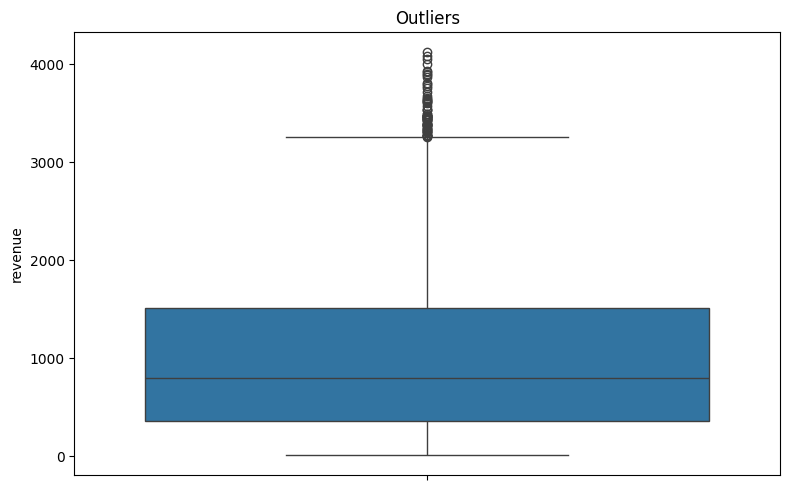

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='revenue')
plt.title('Outliers')
plt.tight_layout()
plt.show()

### Correlation Matrix

In [10]:
corr = df[num_cols].corr()
print(corr)

                 order_id  customer_id  quantity  unit_price  discount  delivery_days  customer_rating   revenue
order_id         1.000000     0.017504 -0.003368    0.017876  0.011110       0.006196         0.004984  0.009681
customer_id      0.017504     1.000000  0.023097    0.009748 -0.012617      -0.017440         0.020302  0.025499
quantity        -0.003368     0.023097  1.000000    0.001498 -0.004302      -0.008748         0.019168  0.623564
unit_price       0.017876     0.009748  0.001498    1.000000  0.013215       0.015623         0.005025  0.678032
discount         0.011110    -0.012617 -0.004302    0.013215  1.000000      -0.000382         0.012776 -0.139296
delivery_days    0.006196    -0.017440 -0.008748    0.015623 -0.000382       1.000000        -0.017625  0.005444
customer_rating  0.004984     0.020302  0.019168    0.005025  0.012776      -0.017625         1.000000  0.012446
revenue          0.009681     0.025499  0.623564    0.678032 -0.139296       0.005444         0.

### Extract Order_date into numerical form

In [11]:
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_day_of_week'] = df['order_date'].dt.dayofweek
df['is_weekend'] = df['order_date'].dt.dayofweek.isin([5,6]).astype(
int)

## EXPLORATORY DATA ANALYSIS(EDA)

### 1. Distribution of payment_method

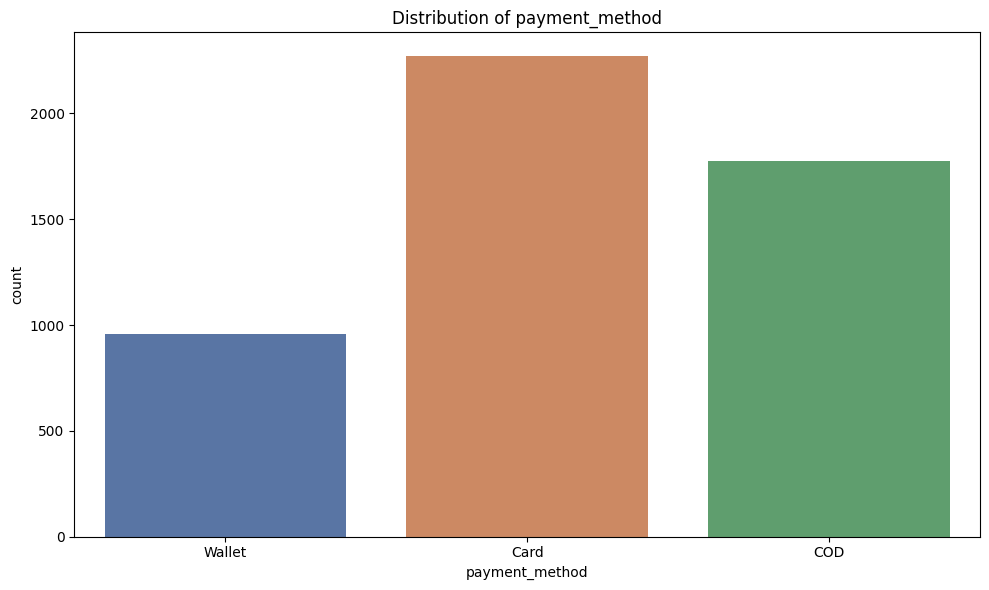

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='payment_method', palette='deep')
plt.title('Distribution of payment_method')
plt.tight_layout()
plt.show()

### 2. Distribution of products_category

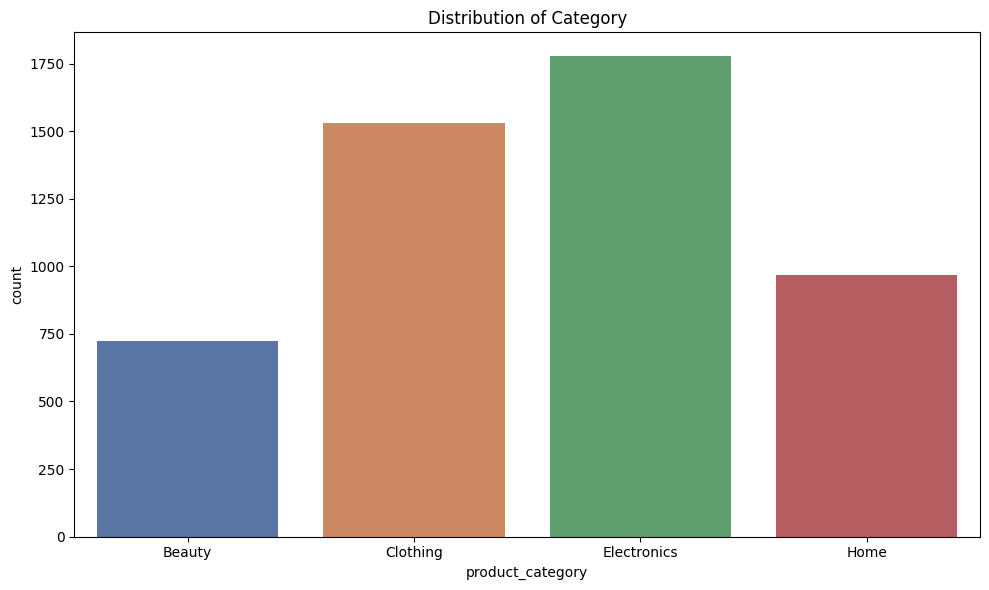

In [13]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='product_category', palette='deep')
plt.title('Distribution of Category',color='black')
plt.tight_layout()
plt.show()

### 3. To show relationship between revenue and product_category

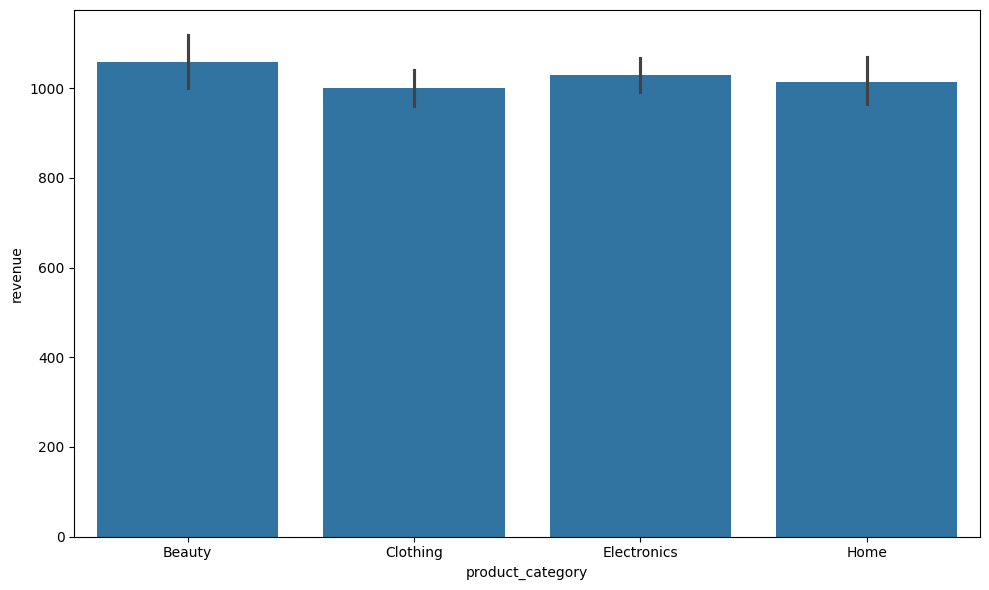

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='product_category', y='revenue')
plt.title('')
plt.tight_layout()
plt.show()

### 4. Distribution of customer_rating

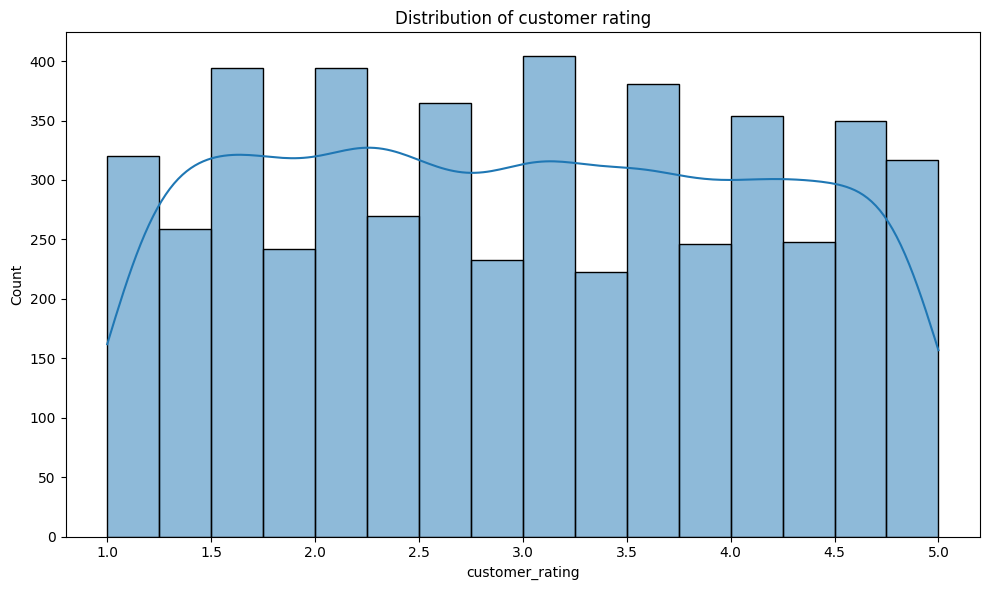

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, bins=16, x='customer_rating', kde=True)
plt.title('Distribution of customer rating')
plt.tight_layout()
plt.show()

### 5. revenue vs unit_price by product_category

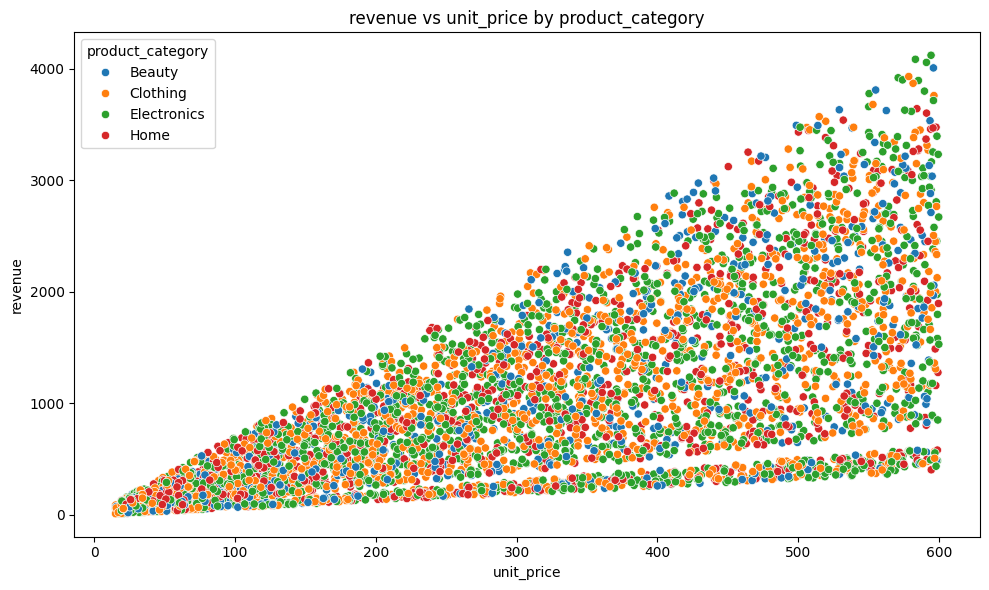

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, hue='product_category', x='unit_price', y='revenue')
plt.title('revenue vs unit_price by product_category')
plt.tight_layout()
plt.show()

### 6. revenue vs product_category

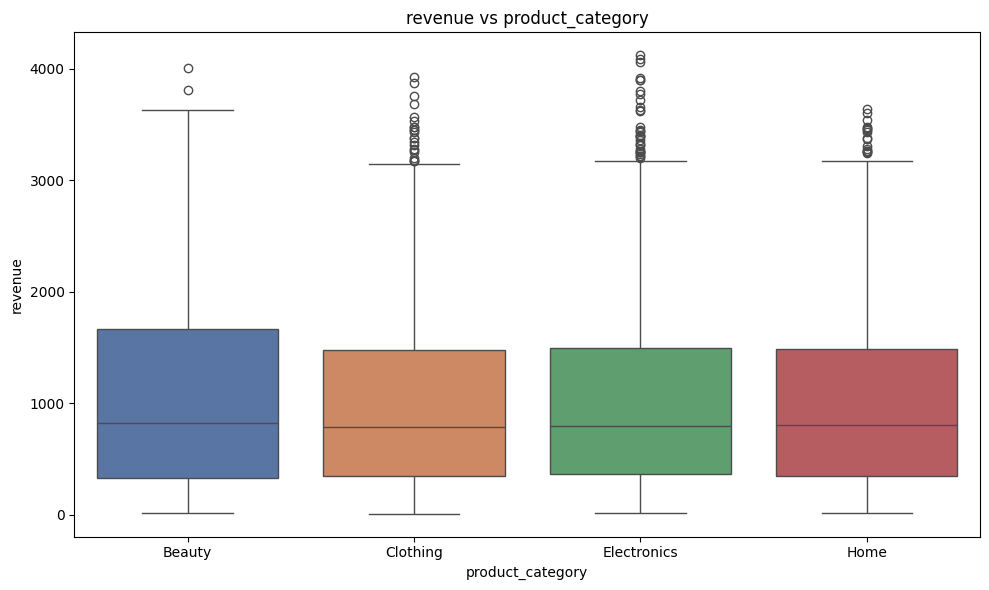

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='revenue', palette='deep')
plt.title('revenue vs product_category')
plt.tight_layout()
plt.show()

### 7. unit_price vs product_category

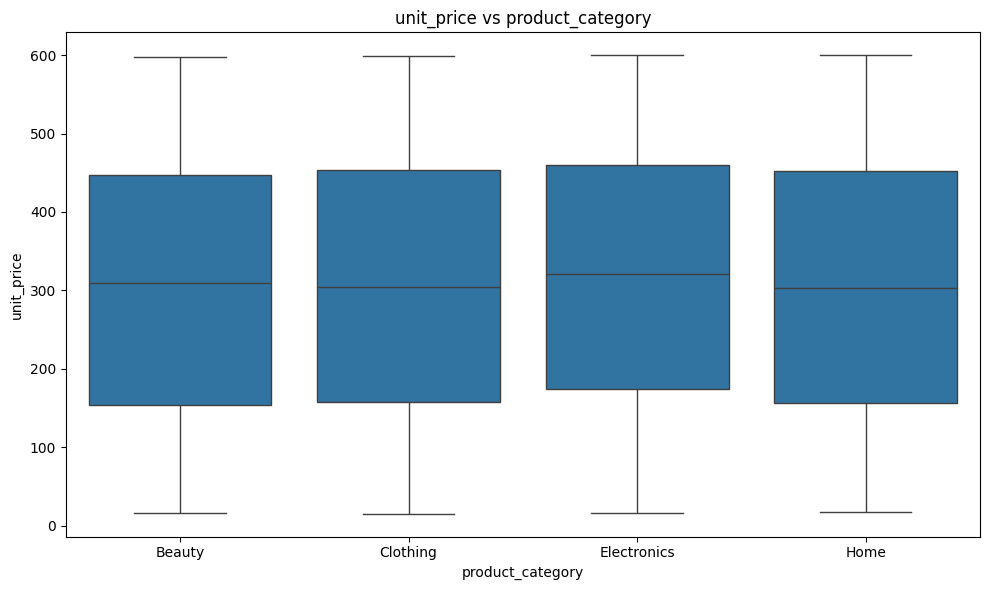

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='product_category', y='unit_price')
plt.title('unit_price vs product_category')
plt.tight_layout()
plt.show()

### 8. revenue vs quantity

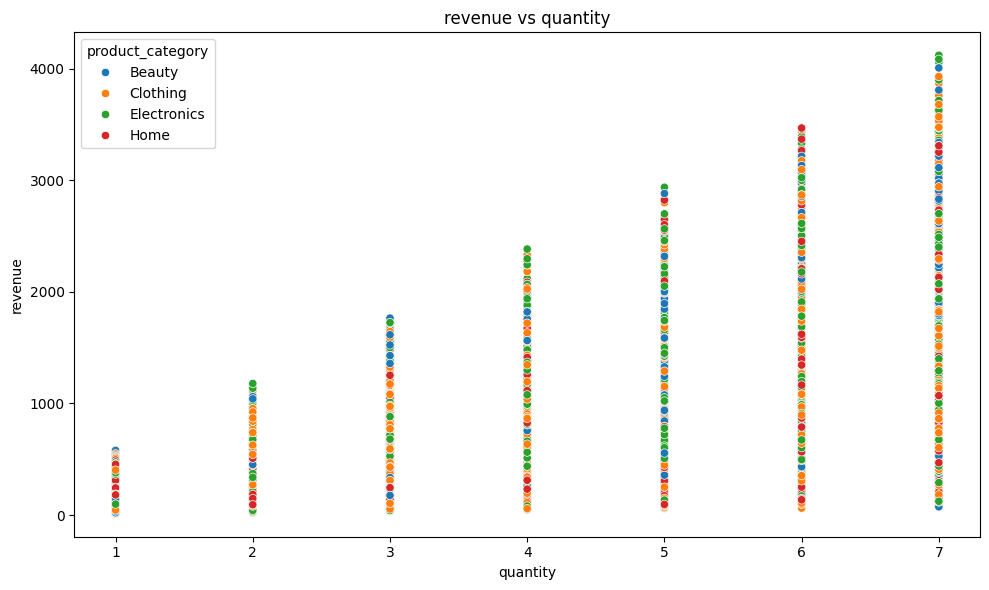

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, y='revenue', x='quantity', hue='product_category')
plt.title('revenue vs quantity')
plt.tight_layout()
plt.show()

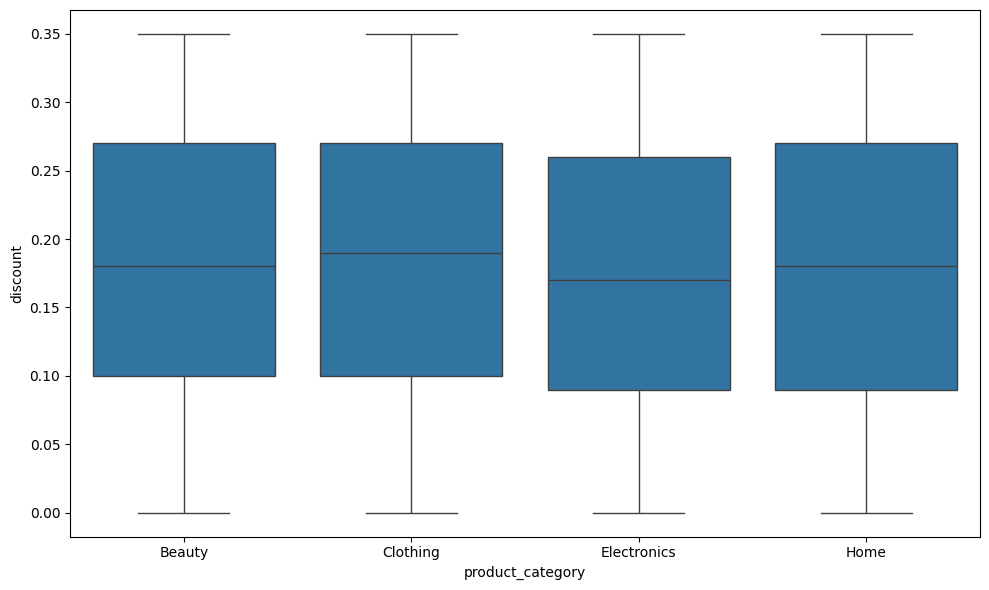

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, y='discount', x='product_category')
plt.title('')
plt.tight_layout()
plt.show()

### 9. Distribution of revenue

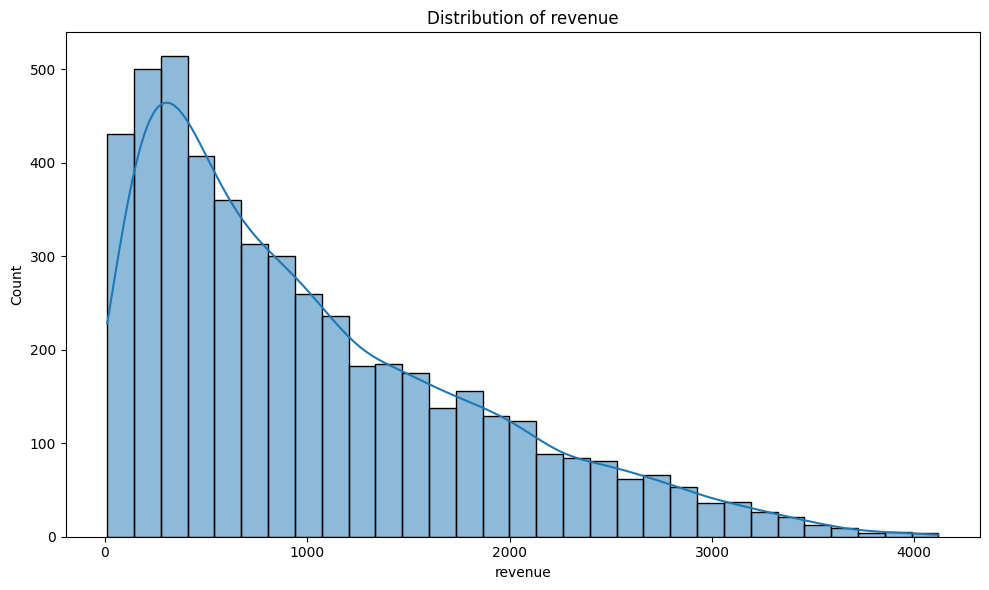

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='revenue', kde=True)
plt.title('Distribution of revenue')
plt.tight_layout()
plt.show()

### Relationship Total_revenue_per_days_of_week

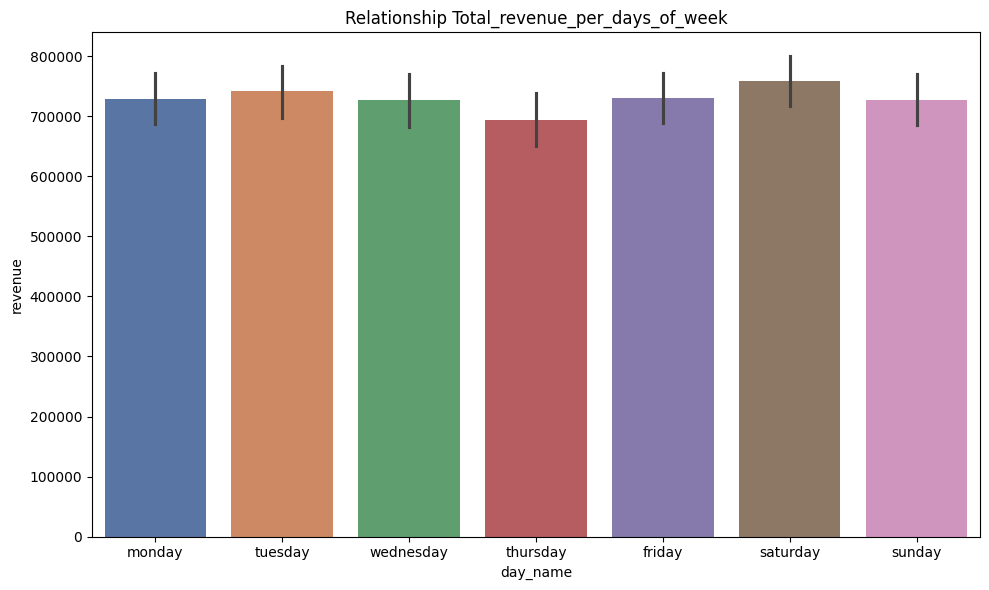

In [22]:
day_mapping = {0:'monday',1:'tuesday',2:'wednesday',3:'thursday',4:'friday',5:'saturday',6:'sunday'}
df['day_name'] = df['order_day_of_week'].map(day_mapping)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x='day_name', estimator=sum, y='revenue',  order=['monday','tuesday','wednesday','thursday','friday','saturday','sunday'], palette='deep')
plt.title('Relationship Total_revenue_per_days_of_week')
plt.tight_layout()
plt.show()

### Numerical relationship plot

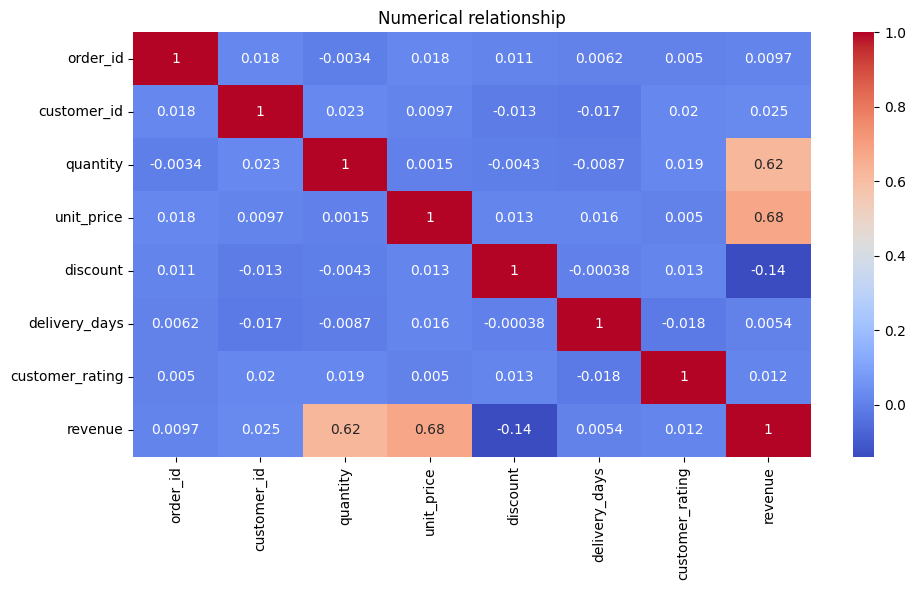

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Numerical relationship')
plt.tight_layout()
plt.show()

## FEATURES ENGINEERING AND PREDICTIONS

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

### copy data

In [25]:
data = df.copy()

### Create variable target

In [26]:
target = 'revenue'

### Remove unrelated columns

In [27]:
data = data.drop(columns=['order_id','customer_id','order_date'])

### create variable X and Y

In [28]:
X = data.drop(columns=[target])
Y = data[target]

In [29]:
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

### processing of the data

In [30]:
# for numerical data
num_pipe = Pipeline([('imputer',SimpleImputer(strategy='median')),
('scaler',StandardScaler())])

# For categorical data
cat_pipe = Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),
('encoder',OneHotEncoder(handle_unknown='ignore'))])

### Model for Training

In [31]:
model = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

### Combine Processes

In [32]:
# uses of ColumnTransfer to combine Pipeline Process
Preprocess = ColumnTransformer([('num',num_pipe,num_cols),
('cat',cat_pipe,cat_cols)])

In [33]:
pipeline = Pipeline([('process',Preprocess),
('model',model)])

### Split train and test data

In [34]:
x_train,x_test,y_train,y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

### Train the Model

In [35]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('process',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['quantity', 'unit_price', 'discount', 'delivery_days',
       'customer_rating', 'is_weekend'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['product_category', 'region', 'payment_method', 'day_name'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=600,
                                           random_state=42))])

### Prediction of Model

In [36]:
pred = pipeline.predict(x_test)

### Performance of model

In [37]:
print(f"score: {r2_score(y_test,pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test,pred):.2f}")

score: 0.9992
MAE: 17.22


### Create DataFrame of Actual vs Predicted

In [38]:
result = pd.DataFrame({'Actual':y_test.values,
'predicted':pred}).sort_values(by='Actual')
print(result)

      Actual    predicted
574    13.01     2.441526
773    13.26    -7.044605
486    15.52   -17.309957
993    28.46    23.771148
57     29.23    38.732775
..       ...          ...
662  3474.21  3445.191906
82   3474.70  3458.738873
114  3757.89  3726.106444
92   3917.54  3881.701958
278  3928.63  3884.582071

[1000 rows x 2 columns]


### Plot for Actual vs Predicted value

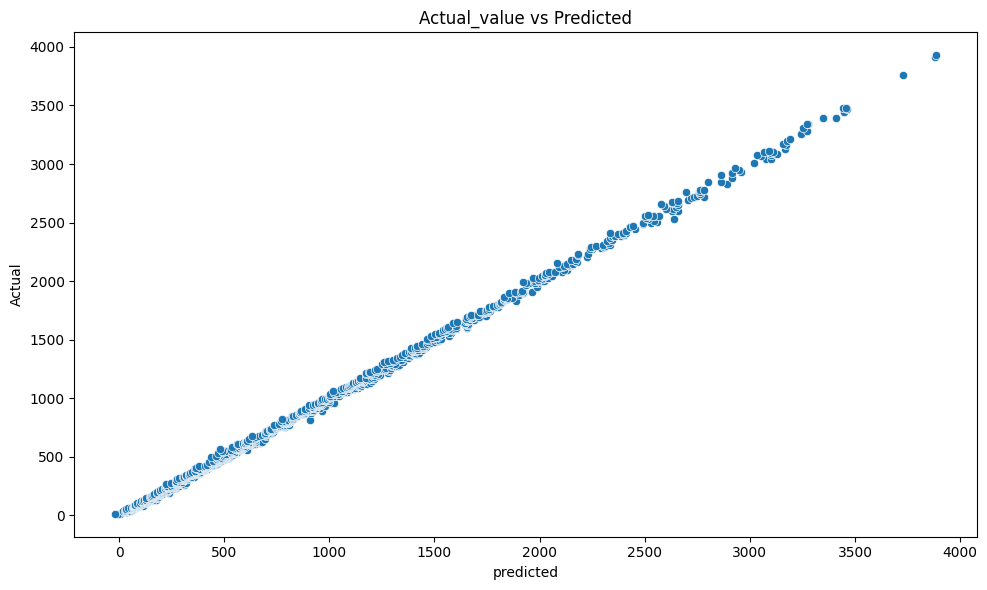

In [39]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=result, y='Actual', x='predicted')
plt.title('Actual_value vs Predicted')
plt.tight_layout()
plt.show()

## 📌 Conclusion & Key Insights

After a thorough Exploratory Data Analysis (EDA) on this E-commerce dataset, here are the major takeaways and data-driven insights:

### 1. 💰 Revenue Drivers (Correlation Analysis)
* **Price & Quantity Dominate:** As expected, `unit_price` ($r = 0.68$) and `quantity` ($r = 0.62$) show a strong positive correlation with `revenue`. They are the primary levers for driving business top-line growth.
* **The Discount Dilemma:** Interestingly, `discount` has a weak negative correlation with revenue ($r = -0.14$). This suggests that while heavy discounting might clear stock, it needs to be carefully optimized so as not to erode overall profitability.

### 2. 📊 Data Anomalies & Anomalous Behavior
* **High-Value Outliers:** Our outlier detection pipeline flagged **67 extreme values** strictly in the `revenue` column. These represent either bulk corporate orders or high-end luxury electronics purchases, which require a specialized strategy (e.g., treating them as a separate B2B segment).
* **Flawless Data Integrity:** The dataset was remarkably clean with **0 duplicate rows** and **0 missing values**, allowing for a seamless preprocessing phase.

### 3. 📅 Feature Engineering Value-Add
* We successfully converted `order_date` into actionable temporal markers (`order_year`, `order_month`, `order_day`, `order_day_of_week`, and `is_weekend`). This paves the way for deeper seasonal forecasting and weekend vs. weekday consumer behavior modeling.

---

## 🚀 Next Steps & Predictive Modeling
To take this project to the next level, the subsequent phases will involve:
1. **Advanced Feature Encoding:** Transforming categorical features like `product_category`, `region`, and `payment_method` using One-Hot Encoding or Target Encoding.
2. **Outlier Mitigation:** Handling the 67 revenue outliers using robust scaling techniques before feeding data into ML algorithms.
3. **Machine Learning:** Implementing Regression models (e.g., *Random Forest Regressor*, *XGBoost*) to predict transaction `revenue` and optimize retail business decisions.

---
### 💞 If you found this notebook helpful and clean, please drop an UPVOTE! It keeps me motivated to share more datasets and analysis! General feedback is highly appreciated in the comments. 📊🚀
